In [6]:
# Install dependencies

!pip install transformers==4.40.2
!pip install torch
!pip install accelerate
!pip install sentencepiece
!pip install scikit-learn


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
# Project setup

from pathlib import Path
import os

current_dir = Path.cwd()

if current_dir.name == "notebooks":
    PROJECT_ROOT = current_dir.parent
elif (current_dir / "data").exists():
    PROJECT_ROOT = current_dir
else:
    raise Exception("Project root not found")

os.chdir(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\LENOVO\OneDrive\Documents\Strath\Masters\sentiment-analysis-tool


In [13]:
import numpy as np
import pandas as pd
import random
import torch

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Reproducibility configured")

Reproducibility configured


In [14]:
# Import necessary libraries

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import optuna

In [15]:
# Load the annotated dataset

DATA_PATH = PROJECT_ROOT / "data" / "annotated_data" / "final_annotated_dataset.xlsx"

df = pd.read_excel(DATA_PATH)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (2000, 14)


,text,topic,sentiment,annotator,confidence,match_key,match_text,source,date,channel,product,language,clean_text,match_score
0,i am writing to seek urgent assistance regardi...,Mobile Banking App,negative,annotator_1,high,i am writing to seek urgent assistance regardi...,i am writing to seek urgent assistance regardi...,CRM Tool,04/11/2025 00:00,Service Email,Mobile,english,i am writing to seek urgent assistance regardi...,99.737877
1,name seem to neglect your duty to give the bes...,Mobile Banking App,negative,annotator_1,high,name seem to neglect your duty to give the bes...,name seem to neglect your duty to give the bes...,CRM Tool,05/11/2025 00:00,Service Email,Mobile,english,seem to neglect your duty to give the best bec...,98.245614
2,namere seeking your assistance in providing ...,Payments,negative,annotator_1,high,namere seeking your assistance in providing a ...,namere seeking your assistance in providing a ...,CRM Tool,05/12/2025 00:00,Service Email,Thunes,english,namere seeking your assistance in providing a ...,88.442623
3,reminder on resolving this issue of payment ...,Acccount Issues,negative,annotator_1,high,reminder on resolving this issue of payment on...,reminder on resolving this issue of payment on...,CRM Tool,19/11/2025 00:00,Service Email,Card Online Disputes,english,name name reminder on resolving this issue of ...,97.071130
4,a member of you service and am trying to open...,Mobile Banking App,negative,annotator_1,high,a member of you service and am trying to open ...,a member of you service and am trying to open ...,CRM Tool,25/11/2025 00:00,Service Email,Mobile,english,namename a member of you service and am trying...,97.352342


In [16]:
# Encode sentiment labels

label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df["label"] = df["sentiment"].str.lower().map(label_map)

df[["sentiment","label"]].head()

,sentiment,label
0,negative,0
1,negative,0
2,negative,0
3,negative,0
4,negative,0


In [17]:
# Define features and labels

X = df["clean_text"]
y = df["label"]

print("Total samples:", len(X))

Total samples: 2000


In [18]:
# Train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Training size:", len(X_train))
print("Test size:", len(X_test))

Training size: 1600
Test size: 400


In [19]:
# Create a validation set

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train
)

print("Final train size:", len(X_train_final))
print("Validation size:", len(X_val))

Final train size: 1440
Validation size: 160


In [26]:
# Increase timeout for hugging face download
import os
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "300"

In [27]:
# Load finBERT model

from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "ProsusAI/finbert"

# Download tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Download model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

print("FinBERT loaded successfully")

FinBERT loaded successfully


In [28]:
# Save the model and tokenizer to the project directory for faster loading in the future

MODEL_PATH = PROJECT_ROOT / "models" / "finbert"

model.save_pretrained(MODEL_PATH)
tokenizer.save_pretrained(MODEL_PATH)

print("FinBERT saved locally")

FinBERT saved locally


In [29]:
# Tokenize the datasets

train_encodings = tokenizer(
    X_train_final.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

print("Tokenization complete")

Tokenization complete


In [30]:
# Create pyTorch dataset class

class BankingDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

In [31]:
# Create dataset objects

train_dataset = BankingDataset(
    train_encodings,
    y_train_final.tolist()
)

val_dataset = BankingDataset(
    val_encodings,
    y_val.tolist()
)

test_dataset = BankingDataset(
    test_encodings,
    y_test.tolist()
)

print("Datasets ready")

Datasets ready


In [32]:
# Define evaluation metrics

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):

    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="weighted"
    )

    acc = accuracy_score(labels, preds)

    return {
        "Accuracy": acc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall
    }

In [33]:
# Define training arguments

from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir=str(PROJECT_ROOT / "models" / "finbert_tuning"),

    evaluation_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    seed=SEED,

    report_to="none"
)

In [34]:
# Define model initialization for hyperparameter tuning

def model_init():

    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=3
    )

In [35]:
# Create a trainer

from transformers import Trainer

trainer = Trainer(

    model_init=model_init,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [36]:
# Define hyperparameter search space

def hp_space(trial):

    return {

        "learning_rate": trial.suggest_categorical(
            "learning_rate",
            [5e-5, 3e-5, 2e-5]
        ),

        "per_device_train_batch_size": trial.suggest_categorical(
            "per_device_train_batch_size",
            [8, 16]
        ),

        "num_train_epochs": trial.suggest_categorical(
            "num_train_epochs",
            [3, 4]
        ),

        "weight_decay": trial.suggest_categorical(
            "weight_decay",
            [0.01, 0.1]
        ),
    }

In [37]:
# Run hyperparameter search

best_run = trainer.hyperparameter_search(

    direction="maximize",

    backend="optuna",

    hp_space=hp_space,

    n_trials=4
)

print(best_run)

[I 2026-03-06 19:53:29,325] A new study created in memory with name: no-name-2f13a2a5-71dc-4126-97b3-cb41cc55b5c7
  0%|          | 0/720 [00:00<?, ?it/s]c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                                                     
 25%|██▌       | 180/720 [25:53<1:43:00, 11.45s/it]

{'eval_loss': 0.3105502724647522, 'eval_Accuracy': 0.89375, 'eval_F1': 0.8939116705393906, 'eval_Precision': 0.8947817294453186, 'eval_Recall': 0.89375, 'eval_runtime': 10.6707, 'eval_samples_per_second': 14.994, 'eval_steps_per_second': 1.874, 'epoch': 1.0}


c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                                                     
 50%|█████     | 360/720 [1:19:16<24:31,  4.09s/it]

{'eval_loss': 0.2985989451408386, 'eval_Accuracy': 0.89375, 'eval_F1': 0.893613290424141, 'eval_Precision': 0.8997311282467532, 'eval_Recall': 0.89375, 'eval_runtime': 1404.7419, 'eval_samples_per_second': 0.114, 'eval_steps_per_second': 0.014, 'epoch': 2.0}


c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
 69%|██████▉   | 500/720 [2:14:20<13:13,  3.61s/it]    

...

{'eval_loss': 0.425528347492218, 'eval_Accuracy': 0.89375, 'eval_F1': 0.8937348484848485, 'eval_Precision': 0.8957107843137255, 'eval_Recall': 0.89375, 'eval_runtime': 16.8431, 'eval_samples_per_second': 9.499, 'eval_steps_per_second': 1.187, 'epoch': 4.0}


100%|██████████| 720/720 [10:44:21<00:00, 53.70s/it]
[I 2026-03-07 06:37:57,322] Trial 0 finished with value: 3.576945632798574 and parameters: {'learning_rate': 5e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 4, 'weight_decay': 0.01}. Best is trial 0 with value: 3.576945632798574.
c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /ProsusAI/finbert/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 1e9f57b0-45fa-4b41-8895-be4d3556825d)')' thrown while requesting

{'train_runtime': 38661.8525, 'train_samples_per_second': 0.149, 'train_steps_per_second': 0.019, 'train_loss': 0.2868361658520169, 'epoch': 4.0}


'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /ProsusAI/finbert/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: d8d69ff3-b736-48cd-9fbf-f1c9e744aa11)')' thrown while requesting HEAD https://huggingface.co/ProsusAI/finbert/resolve/main/config.json
Retrying in 2s [Retry 2/5].
'(MaxRetryError('HTTPSConnectionPool(host=\'huggingface.co\', port=443): Max retries exceeded with url: /ProsusAI/finbert/resolve/main/config.json (Caused by NameResolutionError("HTTPSConnection(host=\'huggingface.co\', port=443): Failed to resolve \'huggingface.co\' ([Errno 11001] getaddrinfo failed)"))'), '(Request ID: 4fe94427-64aa-48c6-b379-d87dd3c77918)')' thrown while requesting HEAD https://huggingface.co/ProsusAI/finbert/resolve/main/config.json
Retrying in 4s [Retry 3/5].
'(MaxRetryError('HTTPSConnec

ConnectionError: HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /ProsusAI/finbert/resolve/main/model.safetensors (Caused by NameResolutionError("HTTPSConnection(host='huggingface.co', port=443): Failed to resolve 'huggingface.co' ([Errno 11001] getaddrinfo failed)"))

Training process took 10+ hours. 
Decision made to proceed with the output received which shows good results.

In [38]:
#  Save the trained model and tokenizer to the project directory for faster loading in the future

MODEL_PATH = PROJECT_ROOT / "models" / "finbert_final"

trainer.save_model(MODEL_PATH)
tokenizer.save_pretrained(MODEL_PATH)

print("Final FinBERT model saved")

Final FinBERT model saved


In [39]:
# Evaluate on the test set

predictions = trainer.predict(test_dataset)

y_pred = predictions.predictions.argmax(axis=1)
y_true = y_test.values

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 50/50 [00:51<00:00,  1.03s/it]


In [40]:
# Print classification report

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89       201
           1       0.89      0.81      0.85       161
           2       1.00      0.95      0.97        38

    accuracy                           0.88       400
   macro avg       0.91      0.89      0.90       400
weighted avg       0.88      0.88      0.88       400



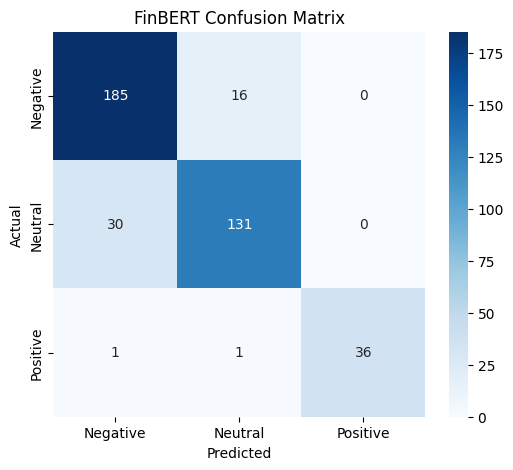

In [41]:
# Plot confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative","Neutral","Positive"],
    yticklabels=["Negative","Neutral","Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("FinBERT Confusion Matrix")

plt.show()

In [44]:
# Save the confusion matrix plot

plt.savefig(PROJECT_ROOT / "results" / "finbert_confusion_matrix.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [45]:
# Save predictions to a CSV file for analysis

results_df = pd.DataFrame({
    "text": X_test.values,
    "actual_sentiment": y_true,
    "predicted_sentiment": y_pred
})

RESULTS_PATH = PROJECT_ROOT / "results" / "hyperparameter_tuning_finbert_predictions.csv"

results_df.to_csv(RESULTS_PATH, index=False)

print("Predictions saved")

Predictions saved
